# Kriging (nugget mode) on the noisy Branin 2D function (R)

This notebook demonstrates `Kriging` with `noise="nugget"`, which estimates a **global nugget**
effect (homoscedastic noise variance) from the data. Unlike `Kriging` with noise vector
where noise variances are known and provided per point, here the nugget is
a single scalar that is optimised alongside the other hyperparameters.

Steps:
1. Install rlibkriging (run once)
2. Load rlibkriging
3. Define the Branin function and add noise
4. Build a space-filling design and evaluate it
5. Fit a `Kriging` with `noise="nugget"` model
6. Predict on a fine grid and plot mean + uncertainty
7. Inspect model parameters (including the estimated nugget)

## 0. Installation (run once)

Build the C++ core and the R binding from source.
Requires: `cmake`, a C++ compiler, and R development headers.

The script `tools/r-linux-macos/build.sh` calls `tools/linux-macos/build.sh`
to build the C++ core, then runs `make` in `bindings/R` to compile and install
**rlibkriging** into `bindings/R/Rlibs`.

In [1]:
# Run this cell once to build and install rlibkriging.
# Skip if already built (bindings/R/Rlibs/rlibkriging exists).
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
rlibs     <- file.path(repo_root, "bindings", "R", "Rlibs", "rlibkriging")

if (!dir.exists(rlibs)) {
  message("Building rlibkriging from source…")
  ret <- system(paste0("cd '", repo_root, "' && bash tools/r-linux-macos/build.sh"))
  if (ret != 0) stop("Build failed — check compiler and cmake installation.")
} else {
  message("rlibkriging already built, skipping.")
}

rlibkriging already built, skipping.



## 1. Load rlibkriging

In [2]:
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
lib_path  <- file.path(repo_root, "bindings", "R", "Rlibs")
library(rlibkriging, lib.loc = lib_path)


Attachement du package : ‘rlibkriging’




L'objet suivant est masqué depuis ‘package:stats’:

    kernel




Les objets suivants sont masqués depuis ‘package:base’:

    beta, load, save




## 2. Noisy Branin function

Same as the `Kriging` with noise vector example: the Branin function on $[0,1]^2$
with additive Gaussian noise ($\sigma_{\varepsilon} = 5$).

The difference is that here we **do not tell** the model the noise level.
Instead, `Kriging` with `noise="nugget"` will estimate a single global nugget from the data.

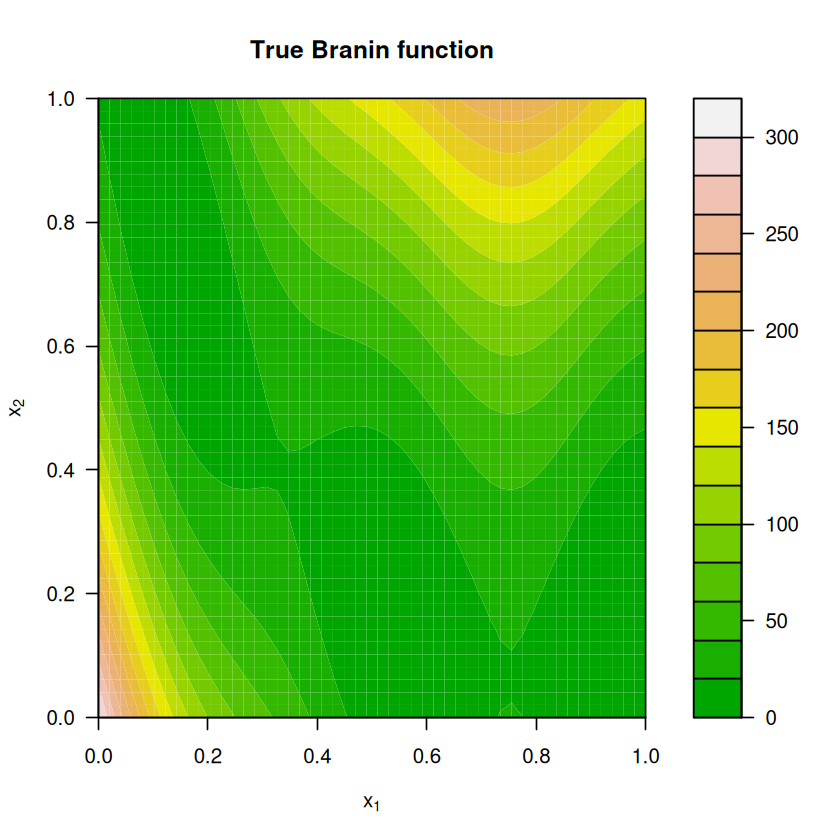

In [3]:
branin <- function(x) {
  if (!is.matrix(x)) x <- matrix(x, nrow = 1)
  x1 <- x[, 1] * 15 - 5
  x2 <- x[, 2] * 15
  (x2 - 5 / (4 * pi^2) * x1^2 + 5 / pi * x1 - 6)^2 +
    10 * (1 - 1 / (8 * pi)) * cos(x1) + 10
}

# Visualise true function on a 50x50 grid
grid_x <- seq(0, 1, length.out = 50)
grid   <- as.matrix(expand.grid(x1 = grid_x, x2 = grid_x))
z_true <- matrix(branin(grid), 50, 50)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = "True Branin function",
  xlab = expression(x[1]), ylab = expression(x[2])
)

## 3. Design of experiments (with noise)

We sample $n = 40$ points using a Latin Hypercube Design and add
Gaussian noise with $\sigma_{\varepsilon} = 5$.

Unlike `Kriging` with noise vector, we do **not** pass noise variances — the model
estimates a single nugget parameter.

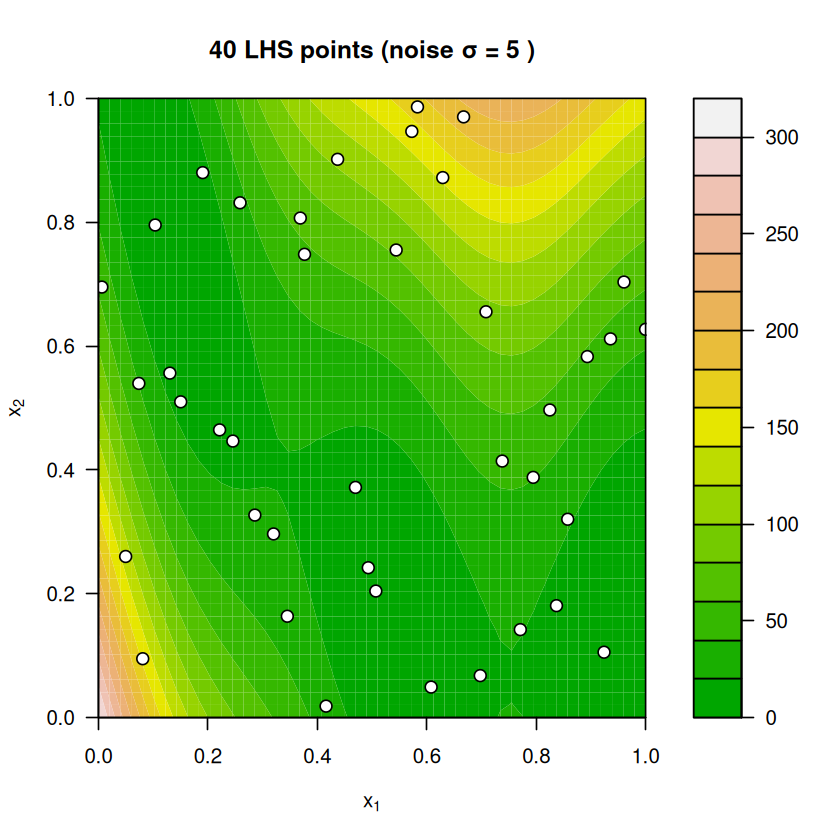

In [4]:
set.seed(42)
n <- 40
noise_sd <- 5.0

lhs <- function(n, d) {
  X <- matrix(NA, n, d)
  for (j in seq_len(d))
    X[, j] <- (sample(n) - runif(n)) / n
  X
}
X <- lhs(n, 2)
y_true <- branin(X)
y <- y_true + noise_sd * rnorm(n)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = paste(n, "LHS points (noise σ =", noise_sd, ")"),
  xlab = expression(x[1]), ylab = expression(x[2]),
  plot.axes = {
    axis(1); axis(2)
    points(X[, 1], X[, 2], pch = 21, bg = "white", cex = 1.2)
  }
)

## 4. Fit a Kriging (nugget mode) model

`Kriging(noise="nugget")` has the same interface as `Kriging()` (no `noise` argument).
It automatically estimates the nugget effect (noise ratio) during fitting.

In [5]:
k <- Kriging(y, X, kernel = "matern5_2", optim = "BFGS10", noise="nugget")
print(k)

* data: 40x[0.00628012,0.999961],[0.0185185,0.986238] -> 40x[-6.12309,185.45]
* trend constant (est.): 227.84
* variance (est.): 54360.5
* covariance:
  * kernel: matern5_2
  * range (est.): 0.663571, 1.5947
  * nugget (est.): 24.4273
  * fit:
    * objective: LL
    * optim: BFGS10


## 5. Predict on a fine grid

`predict()` returns the posterior mean and standard deviation.
The mean is a smooth estimate of the underlying function.

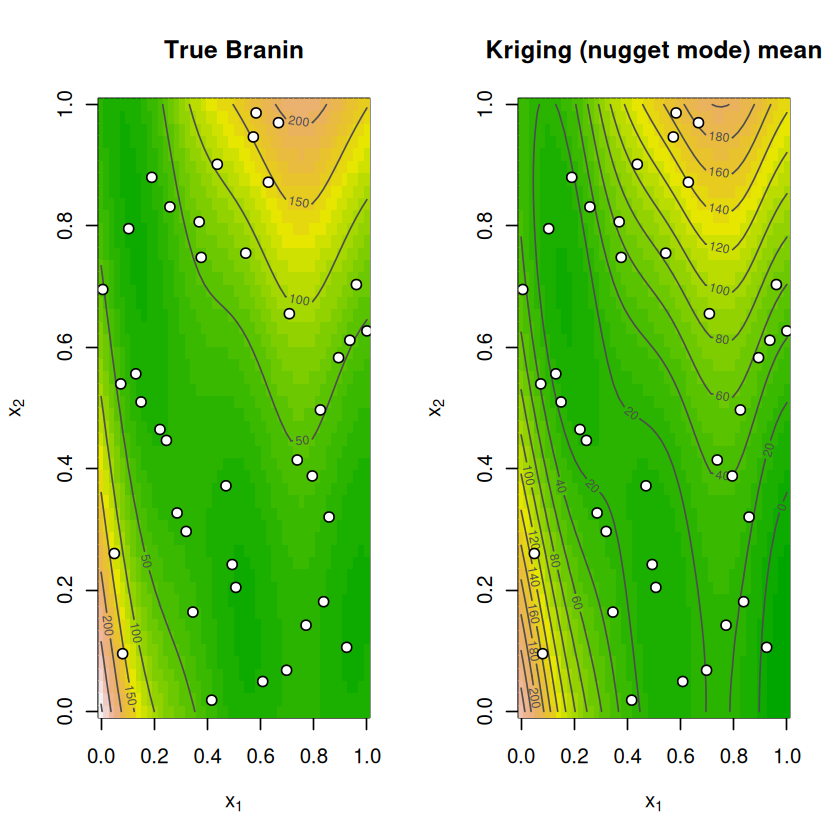

In [6]:
p <- predict(k, grid, return_stdev = TRUE)
z_mean <- matrix(p$mean,  50, 50)
z_sd   <- matrix(p$stdev, 50, 50)

brks <- seq(min(z_true, z_mean), max(z_true, z_mean), length.out = 30)
cols <- terrain.colors(length(brks) - 1)

par(mfrow = c(1, 2))

image(grid_x, grid_x, z_true, breaks = brks, col = cols,
      main = "True Branin", xlab = expression(x[1]), ylab = expression(x[2]))
contour(grid_x, grid_x, z_true, add = TRUE, col = "grey30", nlevels = 10)
points(X[, 1], X[, 2], pch = 21, bg = "white")

image(grid_x, grid_x, z_mean, breaks = brks, col = cols,
      main = "Kriging (nugget mode) mean", xlab = expression(x[1]), ylab = expression(x[2]))
contour(grid_x, grid_x, z_mean, add = TRUE, col = "grey30", nlevels = 10)
points(X[, 1], X[, 2], pch = 21, bg = "white")

par(mfrow = c(1, 1))

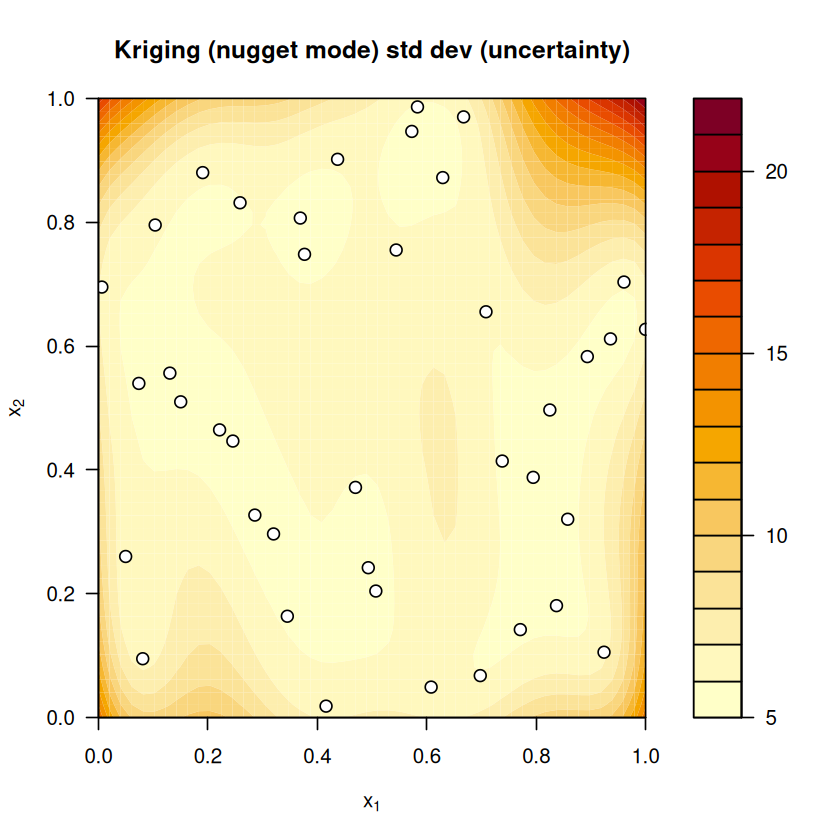

In [7]:
# Posterior standard deviation (uncertainty)
filled.contour(
  grid_x, grid_x, z_sd,
  color.palette = function(n) hcl.colors(n, "YlOrRd", rev = TRUE),
  main = "Kriging (nugget mode) std dev (uncertainty)",
  xlab = expression(x[1]), ylab = expression(x[2]),
  plot.axes = {
    axis(1); axis(2)
    points(X[, 1], X[, 2], pch = 21, bg = "white", cex = 1.2)
  }
)

## 6. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$,
**nugget**, and the log-likelihood at the optimum.

The nugget represents the estimated noise-to-signal ratio.
Compare it with the true noise variance: $\sigma_{\varepsilon}^2 = 25$.

In [8]:
cat("Kernel       :", k$kernel(), "\n")
cat("Theta (range):", round(k$theta(), 4), "\n")
cat("Sigma2       :", round(k$sigma2(), 4), "\n")
cat("Nugget       :", round(k$nugget(), 4), "\n")
cat("LogLikelihood:", round(k$logLikelihood(), 4), "\n")
cat("\n")
cat("Estimated noise variance (nugget × sigma2):", round(k$nugget() * k$sigma2(), 2), "\n")
cat("True noise variance:                       ", noise_sd^2, "\n")

Kernel       : matern5_2 


Theta (range): 0.6636 1.5947 


Sigma2       : 54360.51 


Nugget       : 24.4273 


LogLikelihood: -161.75 


Estimated noise variance (nugget × sigma2): 1327880 


True noise variance:                        25 


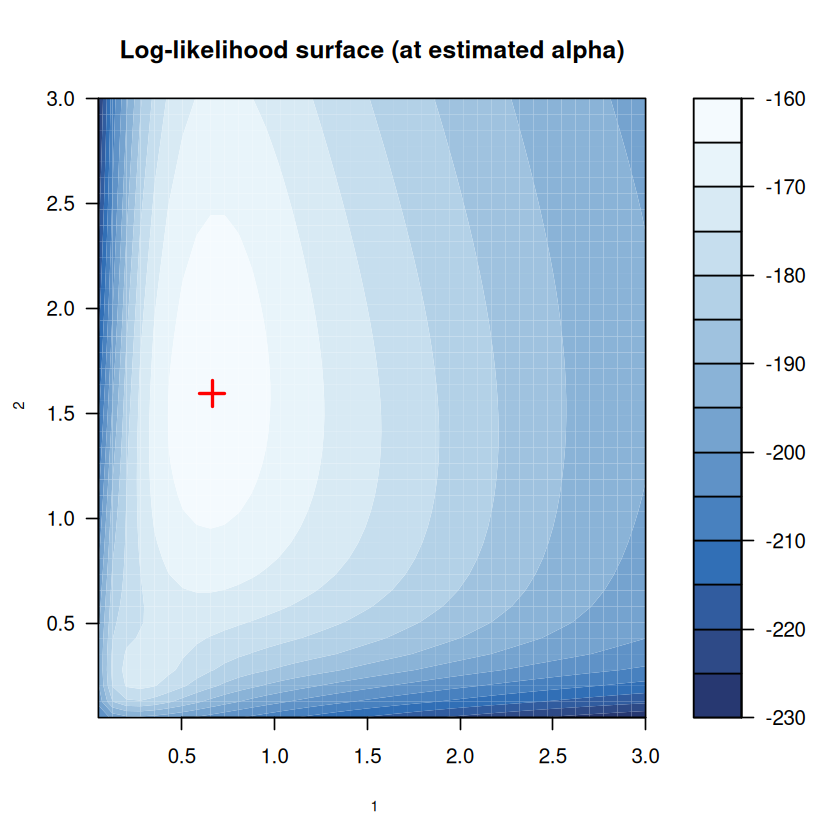

In [9]:
# Log-likelihood surface as a function of the two length-scales
# Kriging logLikelihoodFun (nugget mode) expects theta_alpha = c(theta1, theta2, alpha)
# where alpha = sigma2 / (sigma2 + nugget)
alpha_hat <- k$sigma2() / (k$sigma2() + k$nugget())
theta_grid <- seq(0.05, 3, length.out = 40)
ll_mat <- outer(
  theta_grid, theta_grid,
  Vectorize(function(t1, t2) k$logLikelihoodFun(matrix(c(t1, t2, alpha_hat), nrow = 1))$logLikelihood)
)

filled.contour(
  theta_grid, theta_grid, ll_mat,
  color.palette = function(n) hcl.colors(n, "Blues"),
  main = "Log-likelihood surface (at estimated alpha)",
  xlab = expression(theta[1]), ylab = expression(theta[2]),
  plot.axes = {
    axis(1); axis(2)
    points(k$theta()[1], k$theta()[2], pch = 3, lwd = 2, col = "red", cex = 2)
  }
)